# Nonlinear C-yoke: HDiv-MMM, reduced-A, and omega-reduced-omega

This notebook records the final nonlinear order-2 accuracy certificate for the
exact Cubit/ACIS C-yoke. HDiv-MMM uses the iron-only mesh and its Coulomb open
boundary. HCurl reduced-A and H1 omega-reduced-omega use the same locally
refined physical-air sphere and periodic Kelvin sphere; no finite outer air box
is introduced.

The certificate does not claim an unavailable analytic truth for this nonlinear
three-dimensional model. It requires all three formulations to converge under
geometric mesh refinement, bounds their fine-mesh spread, and requires an
independent-host reproduction with identical mesh, software, material, and
observation contracts. The accepted quantity is the gauge-invariant magnetic
flux density B in the useful gap core.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "validation_test").is_dir():
            return candidate
    raise RuntimeError("Radia repository root was not found")


REPO = find_repo_root(Path.cwd().resolve())
RESULTS = REPO / "validation_test" / "c_type_three_engine" / "results"
CERTIFICATE_PATH = RESULTS / "mdx_hibino_20260830_nonlinear_order2_convergence.json"
LEVEL_NAMES = ("coarse", "medium", "fine", "finer")
LEVEL_PATHS = {
    name: RESULTS / f"mdx_20260830_nonlinear_order2_{name}.json"
    for name in LEVEL_NAMES
}
REPLICATE_PATH = RESULTS / "hibino_20260830_nonlinear_order2_finer_replicate.json"

certificate = json.loads(CERTIFICATE_PATH.read_text(encoding="utf-8"))
levels = {name: json.loads(path.read_text(encoding="utf-8")) for name, path in LEVEL_PATHS.items()}
replicate = json.loads(REPLICATE_PATH.read_text(encoding="utf-8"))
assert certificate["schema"] == "radia.validation.c-type-absolute-accuracy-certificate.v1"
assert certificate["passed"] is True
certificate["claim"]

{'quantity': 'gauge-invariant B in the C-yoke useful gap core',
 'analytic_absolute_truth_claimed': False,
 'certified_statement': 'three independent formulations converge toward one common mesh-refined field within the reported numerical envelope',
 'scope': 'nonlinear order-2 Cubit/ACIS C-type model with Kelvin open boundary'}

## Mesh convergence and numerical envelope

In [2]:
engines = ("hdiv_mmm", "reduced_a", "omega_reduced_omega")
labels = {
    "hdiv_mmm": "HDiv-MMM",
    "reduced_a": "HCurl reduced-A",
    "omega_reduced_omega": "H1 omega-reduced-omega",
}

rows = [
    "| level | iron / Kelvin elements | HDiv / reduced-A / omega DoF | HDiv / reduced-A / omega runtime (s) | max pairwise gap-core RMS |",
    "|---|---:|---:|---:|---:|",
]
for name in LEVEL_NAMES:
    level = levels[name]
    diagnostic = level["engines"]
    rows.append(
        f"| {name} | {diagnostic['hdiv_mmm']['mesh_elements']:,} / {diagnostic['reduced_a']['mesh_elements']:,} "
        f"| {diagnostic['hdiv_mmm']['ndof']:,} / {diagnostic['reduced_a']['ndof']:,} / {diagnostic['omega_reduced_omega']['ndof']:,} "
        f"| {diagnostic['hdiv_mmm']['runtime_s']:.2f} / {diagnostic['reduced_a']['runtime_s']:.2f} / {diagnostic['omega_reduced_omega']['runtime_s']:.2f} "
        f"| {100 * level['maximum_gap_core_pairwise_relative_rms']:.4f}% |"
    )
display(Markdown("\n".join(rows)))

conv_rows = [
    "| formulation | convergence levels | observed order | last-step RMS | Richardson estimate | conservative uncertainty |",
    "|---|---|---:|---:|---:|---:|",
]
for engine in engines:
    row = certificate["engine_convergence"][engine]
    conv_rows.append(
        f"| {labels[engine]} | {' -> '.join(row['convergence_levels'])} "
        f"| {row['observed_order']:.3f} "
        f"| {100 * row['last_increment_relative_rms']:.4f}% "
        f"| {100 * row['richardson_relative_uncertainty']:.4f}% "
        f"| {100 * row['conservative_relative_uncertainty']:.4f}% |"
    )
display(Markdown("\n".join(conv_rows)))

| level | iron / Kelvin elements | HDiv / reduced-A / omega DoF | HDiv / reduced-A / omega runtime (s) | max pairwise gap-core RMS |
|---|---:|---:|---:|---:|
| coarse | 434 / 24,134 | 8,784 / 126,834 / 33,514 | 10.55 / 153.37 / 22.91 | 0.2945% |
| medium | 542 / 36,208 | 10,860 / 190,396 / 50,322 | 11.82 / 209.79 / 38.94 | 0.2258% |
| fine | 846 / 54,886 | 16,608 / 288,902 / 76,422 | 17.64 / 404.59 / 42.22 | 0.3300% |
| finer | 1,688 / 89,454 | 32,580 / 470,288 / 124,132 | 36.78 / 852.08 / 90.41 | 0.2933% |

| formulation | convergence levels | observed order | last-step RMS | Richardson estimate | conservative uncertainty |
|---|---|---:|---:|---:|---:|
| HDiv-MMM | medium -> fine -> finer | 18.543 | 0.0038% | 0.0001% | 0.0038% |
| HCurl reduced-A | medium -> fine -> finer | 0.857 | 0.0371% | 0.1760% | 0.1760% |
| H1 omega-reduced-omega | medium -> fine -> finer | 1.912 | 0.0714% | 0.1342% | 0.1342% |

## Finest-mesh field profile in the useful gap

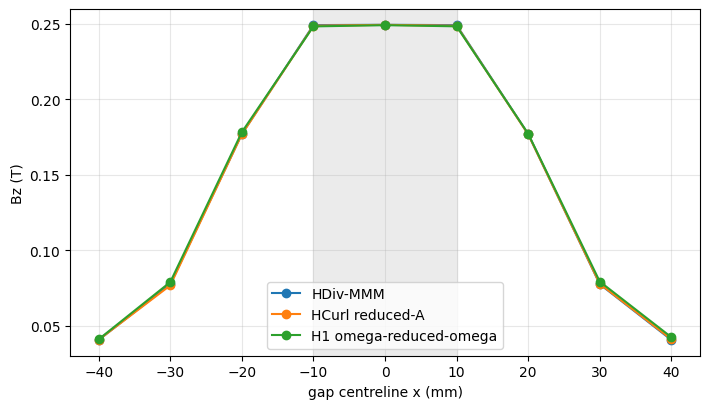

In [3]:
finest = levels["finer"]
points = np.asarray(finest["observation_points_m"], dtype=float)
centreline = np.isclose(points[:, 1], 0.0) & np.isclose(points[:, 2], 0.0)
order = np.argsort(points[centreline, 0])

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for engine in engines:
    field = np.asarray(finest["median_plane_projected_fields_T"][engine], dtype=float)
    ax.plot(points[centreline, 0][order] * 1e3, field[centreline, 2][order], marker="o", label=labels[engine])
ax.axvspan(-10.0, 10.0, color="0.92", zorder=0)
ax.set_xlabel("gap centreline x (mm)")
ax.set_ylabel("Bz (T)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Reproduce the finest HDiv-MMM field

The visualization below reruns the finest iron-only HDiv-MMM problem from the
tracked, checked Cubit mesh. The persistent C++ HDiv field evaluator remains the
field source. A vector L2 grid function is populated only as a display cache so
WebGUI does not repeatedly materialize the external field while the scene is
rotated.

In [4]:
import ngsolve as ng
import radia as rad
from ngsolve.webgui import Draw
from radia import vim

SUITE = REPO / "validation_test" / "c_type_three_engine"
sys.path.insert(0, str(SUITE))
from run_three_engine import MU0, build_coil

MESH_PATH = REPO / "docs" / "hdiv_vim" / "c_type_three_formulation_convergence_iron.vol"
mesh = ng.Mesh(str(MESH_PATH))
bh_path = Path(rad.__file__).resolve().parent / "panels" / "samples" / "em_sample_bh.txt"
bh_table = np.loadtxt(bh_path, dtype=float)[:, :2].tolist()

rad.UtiDelAll()
coil, _coil_contract = build_coil()
source_h = rad.RadiaField(coil, "h")
with ng.TaskManager():
    hdiv_result = vim.Solve(
        mesh,
        H_ext=source_h,
        order=2,
        bh_table=bh_table,
        gram_eps=1.0e-14,
        tol=1.0e-8,
        maxit=12000,
        nl_tol=2.0e-5,
        nl_maxit=80,
        preconditioner="auto",
    )
    demag_h = vim.FieldCoefficientFromSolution(hdiv_result, algorithm="direct")
    total_b = MU0 * (source_h + demag_h + hdiv_result["gfM"])
    b_view = ng.GridFunction(ng.L2(mesh, order=2, dim=3), name="B_display")
    b_view.Set(total_b)

mesh_scene = Draw(
    mesh,
    name="C_type_finest_Cubit_mesh",
    draw_vol=True,
    draw_surf=True,
    width="100%",
    height="420px",
)
field_scene = Draw(
    ng.Norm(b_view),
    mesh,
    name="C_type_total_B_magnitude",
    draw_vol=True,
    draw_surf=True,
    autoscale=True,
    clipping={"z": -1.0, "dist": 0.0},
    width="100%",
    height="500px",
)
field_scene

WebGLScene

## Acceptance summary

In [5]:
summary = {
    "certificate_passed": certificate["passed"],
    "finest_mesh_maximum_pairwise_relative_rms": certificate["fine_mesh_maximum_pairwise_relative_rms"],
    "maximum_discretization_relative_uncertainty": certificate["maximum_discretization_relative_uncertainty"],
    "maximum_consensus_relative_deviation": certificate["maximum_consensus_relative_deviation"],
    "combined_relative_numerical_uncertainty": certificate["combined_relative_numerical_uncertainty"],
    "independent_host_maximum_relative_rms": certificate["reproducibility"]["maximum_relative_rms"],
    "reference_machine": certificate["reproducibility"]["reference_machine"],
    "replicate_machine": certificate["reproducibility"]["replicate_machine"],
    "finest_hdiv_nonlinear_converged": bool(levels["finer"]["engines"]["hdiv_mmm"]["nonlinear_stats"]["converged"]),
    "finest_reduced_a_nonlinear_converged": bool(levels["finer"]["engines"]["reduced_a"]["nonlinear_stats"]["converged"]),
    "finest_omega_nonlinear_converged": bool(levels["finer"]["engines"]["omega_reduced_omega"]["nonlinear_stats"]["converged"]),
}
assert all(summary[key] for key in (
    "certificate_passed",
    "finest_hdiv_nonlinear_converged",
    "finest_reduced_a_nonlinear_converged",
    "finest_omega_nonlinear_converged",
))
summary

{'certificate_passed': True,
 'finest_mesh_maximum_pairwise_relative_rms': 0.002932616931764925,
 'maximum_discretization_relative_uncertainty': 0.0017600931288894205,
 'maximum_consensus_relative_deviation': 0.0018225928287453933,
 'combined_relative_numerical_uncertainty': 0.003582685957634814,
 'independent_host_maximum_relative_rms': 2.3448483982137623e-14,
 'reference_machine': 'mdx',
 'replicate_machine': 'Hibino',
 'finest_hdiv_nonlinear_converged': True,
 'finest_reduced_a_nonlinear_converged': True,
 'finest_omega_nonlinear_converged': True}